# Modelagem preditiva para classificação do nível de obesidade

Este notebook faz parte do Tech Challenge 4 e tem como objetivo desenvolver a etapa de modelagem preditiva.

A base utilizada contém informações físicas, comportamentais e familiares de indivíduos, como idade, altura, peso, histórico familiar, hábitos alimentares, prática de atividade física, consumo de água, uso de dispositivos eletrônicos e meio de transporte.

A variável alvo do projeto é a coluna Obesity, que representa o nível de obesidade de cada indivíduo. O objetivo é treinar modelos de Machine Learning para prever a classificação com assertividade superior a 75%.

Iremos verificar os dados, preparar os pipelines, treinar os modelos (regressão logística, árvore de decisão, random forest e gradient boosting), comparar os resultados e preparar o pipeline para uso na aplicação em Streamlit.

## 1. Importação das bibliotecas

Primeiro importamos as bibliotecas necessárias para manipulação dos dados, criação da pipeline, treinamento dos modelos, avaliação dos resultados e salvamento do modelo final.

- Pandas e numpy: usadas para tratar os dados em formato tabular.  
- Scikit-learn: usada para dividir e tratar variáveis numéricas e categóricas, treinar modelos e avaliar o desempenho.  
- Joblib: usada para salvar o modelo final de modo que que ele seja reutilizado posteriormente na aplicação em Streamlit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Carregamento da base de dados

Nesta etapa, carregamos o arquivo que contém os dados e trazemos as primeiras linhas da base para visualizar a estrutura dos dados.

In [2]:
df = pd.read_csv("../data/Obesity.csv")

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Verificação da estrutura da base

Aqui verificamos a estrutura para entender a quantidade de registros e de colunas, nome das variáveis e seu tipo e até a se há valores nulos ou não.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   str    
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   str    
 5   FAVC            2111 non-null   str    
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   str    
 9   SMOKE           2111 non-null   str    
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   str    
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   str    
 15  MTRANS          2111 non-null   str    
 16  Obesity         2111 non-null   str    
dtypes: float64(8), str(9)
memory usage: 280.5 KB

## 4. Quantidade de linhas e colunas

O comando "shape" retorna o número de linhas e a quantidade de colunas


In [4]:
df.shape

(2111, 17)

## 5. Verificação de valores ausentes

Verificamos se existem valores nulos na base de dados, porque mesmo que a base não apresente valores ausentes, garantimos a qualidade dos dados. Além de tornar o processo mais robusto caso novos dados sejam adicionados num futuro

In [5]:
df.isnull().sum()

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

## 6. Análise da variável alvo

A variável alvo do projeto é a coluna Obesity.
Essa coluna representa a classificação do nível de obesidade de cada indivíduo. Aqui vemos a quantidade de registros em cada classe da variável e entendemos se a base está balanceada ou se existem classes com mais exemplos do que outras.

In [6]:
df["Obesity"].value_counts()

Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

## 7. Distribuição percentual da variável alvo

Além da quantidade total de registros por classe,vemos a distribuição percentual da variável para ver o quanto cada classe representa e mais tarde auxiliar na avaliação mais adequada do desempenho dos modelos

In [7]:
df["Obesity"].value_counts(normalize=True) * 100

Obesity
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64

## 8. Remoção das variáveis Weight e Height

Conforme orientação nas aulas, removemos as variáveis Weight e Height, já que elas possuem relação direta com o cálculo do IMC e como a variável alvo Obesity representa o nível de obesidade, manter peso e altura poderia fazer com que o algoritmo aprendesse a relação da própria regra de classificação do IMC. Removemos também para evitar possível vazamento de informação e para deixar a modelagem mais focada em fatores comportamentais, familiares e de estilo de vida

In [8]:
df_modelagem = df.drop(["Weight", "Height"], axis=1)

df_modelagem.head()

,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 9. Definição das variáveis numéricas e categóricas

Nesta etapa, separamos as variáveis de:
- valores quantitativos em numéricas (idade, consumo de água, refeições diárias e frequência de atividade física)
- texto em categóricas (gênero, histórico familiar, consumo de alimentos calóricos, hábito de fumar e meio de transporte)


In [9]:
numeric_features = [
    "Age",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

categorical_features = [
    "Gender",
    "family_history",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS"
]

## 10. Separação entre variáveis explicativas e variável alvo

Separamos a base em duas partes:

- X: contém as variáveis explicativas, ou seja, as informações que o modelo usará para aprender padrões
- y: contém a variável alvo, ou seja, a informação que queremos prever.

In [10]:
X = df_modelagem.drop("Obesity", axis=1)
y = df_modelagem["Obesity"]

## 11. Codificação da variável alvo

A variável alvo Obesity está em formato textual, com classes como Normal_Weight, Obesity_Type_I e Overweight_Level_I, então usamos o LabelEncoder para transformar as classes em números para ajudar os modelos, já que eles trabalham melhor com valores numéricos

Isso apenas será usado internamente durante o treinamento, o encoder será salvo e depois a aplicação converte de volta para o nome original.

In [11]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

## 12. Conferência da codificação da variável alvo

Exibimos a correspondência entre cada número gerado pelo LabelEncoder e a classe original para garantir que conseguimos interpretar as previsões feitas pelos modelos.

In [12]:
for numero, classe in enumerate(label_encoder.classes_):
    print(numero, "-", classe)

0 - Insufficient_Weight
1 - Normal_Weight
2 - Obesity_Type_I
3 - Obesity_Type_II
4 - Obesity_Type_III
5 - Overweight_Level_I
6 - Overweight_Level_II


## 13. Divisão da base em treino e teste

Dividimos os dados em duas partes:

- base de treino: para o modelo aprender os padrões dos dados;
- base de teste: para avaliar se o modelo consegue fazer boas previsões em dados que ele ainda não tem.

Considerando a divisão de 80% para treino e 20% para teste, trazemos o stratify para manter a proporção das classes da variável alvo nas duas quebras para evitar que alguma classe fique mal representada

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

## 14. Construção da pipeline de pré-processamento

Fazemos dois tipos de tratamento de dados para garantir que seja aplicado tanto durante o treinamento quanto futuramente na aplicação em produção.

Para as variáveis numéricas:
- valores ausentes serão preenchidos com a mediana;
- os dados serão padronizados com StandardScaler.

Para as variáveis categóricas:
- valores ausentes serão preenchidos com o valor mais frequente;
- as categorias serão transformadas em variáveis numéricas usando OneHotEncoder.


In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 15. Criação da função de avaliação dos modelos

Nesta etapa, criamos uma função para treinar e avaliar diferentes modelos de classificação de modo que evite repetição de código e facilite a comparação entre diferentes modelos.

A função recebe o nome do modelo e o algoritmo escolhido. Em seguida, ela:

1. cria uma pipeline completa com pré-processamento e modelo;
2. treina o modelo com os dados de treino;
3. realiza previsões com os dados de teste;
4. calcula a acurácia;
5. exibe o relatório de classificação com precision, recall e f1-score;
6. apresenta a matriz de confusão.


In [15]:
def avaliar_modelo(nome_modelo, modelo):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acuracia = accuracy_score(y_test, y_pred)

    print("=" * 80)
    print(nome_modelo)
    print("Acurácia:", round(acuracia * 100, 2), "%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    matriz = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=label_encoder.classes_
    )

    disp.plot(xticks_rotation=90)
    plt.title(f"Matriz de Confusão - {nome_modelo}")
    plt.show()

    return pipeline, acuracia

## 16. Treinamento do modelo de Regressão Logística

O primeiro modelo testado foi a Regressão Logística, que apesar de simples, ele é útil para comparação e interpretação dos resultados.

Esse modelo será utilizado como uma primeira referência de desempenho para entender qual resultado inicial conseguimos obter com um modelo mais simples.

Regressão Logística
Acurácia: 62.41 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.59      0.72      0.65        54
      Normal_Weight       0.55      0.40      0.46        58
     Obesity_Type_I       0.54      0.73      0.62        70
    Obesity_Type_II       0.58      0.88      0.70        60
   Obesity_Type_III       0.90      0.98      0.94        65
 Overweight_Level_I       0.64      0.47      0.54        58
Overweight_Level_II       0.44      0.12      0.19        58

           accuracy                           0.62       423
          macro avg       0.61      0.61      0.59       423
       weighted avg       0.61      0.62      0.59       423



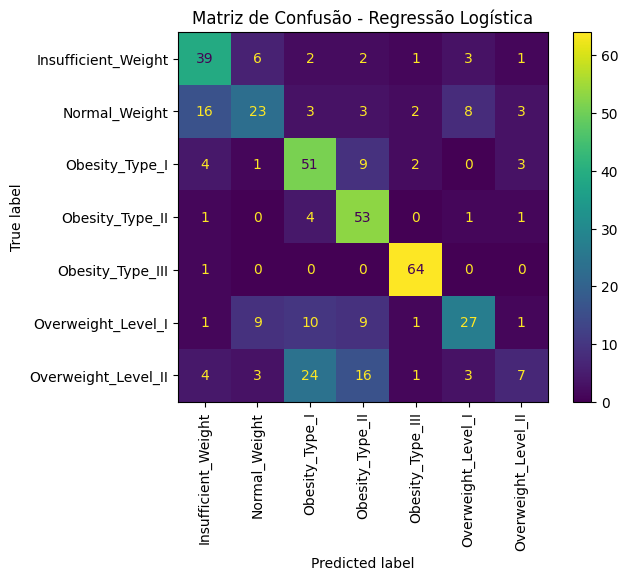

In [16]:
pipeline_log, acc_log = avaliar_modelo(
    "Regressão Logística",
    LogisticRegression(max_iter=2000)
)

## 17. Treinamento do modelo de Árvore de Decisão

O segundo modelo testado foi a Árvore de Decisão por ser um modelo de fácil interpretação, mas ele pode apresentar risco de overfitting, ou seja, pode aprender muito bem os dados de treino e ter pior desempenho considerando dados novos.

Esse algoritmo cria regras de decisão a partir dos dados, separando os registros conforme as características mais relevantes para classificar a variável alvo.


Árvore de Decisão
Acurácia: 74.23 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.73      0.83      0.78        54
      Normal_Weight       0.55      0.48      0.51        58
     Obesity_Type_I       0.63      0.77      0.69        70
    Obesity_Type_II       0.94      0.85      0.89        60
   Obesity_Type_III       0.97      0.98      0.98        65
 Overweight_Level_I       0.73      0.66      0.69        58
Overweight_Level_II       0.65      0.59      0.62        58

           accuracy                           0.74       423
          macro avg       0.74      0.74      0.74       423
       weighted avg       0.74      0.74      0.74       423



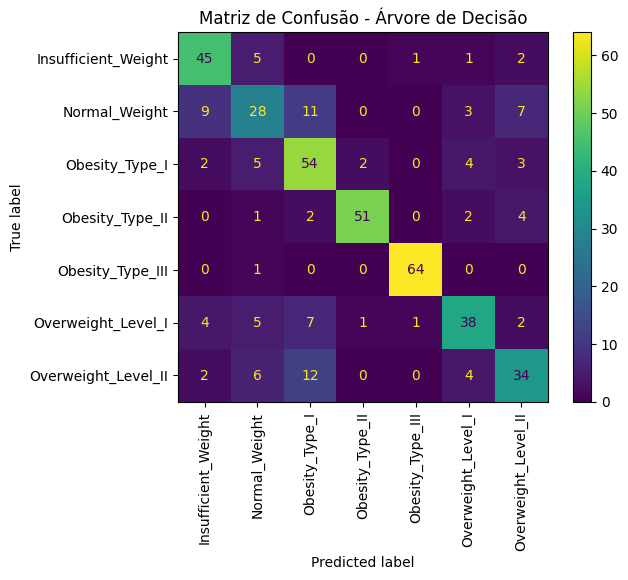

In [17]:
pipeline_tree, acc_tree = avaliar_modelo(
    "Árvore de Decisão",
    DecisionTreeClassifier(random_state=42)
)

## 18. Treinamento do modelo Random Forest

O terceiro modelo testado foi o Random Forestost por apresentar desempenho superior ao de uma árvore de decisão simples.

Esse algoritmo combina várias árvores de decisão para melhorar a capacidade de generalização do modelo. Em vez de depender de uma única árvore, ele utiliza um conjunto de árvores e combina os resultados.


Random Forest
Acurácia: 85.34 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.89      0.91        54
      Normal_Weight       0.66      0.79      0.72        58
     Obesity_Type_I       0.83      0.86      0.85        70
    Obesity_Type_II       0.93      0.92      0.92        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.79      0.76      0.77        58
Overweight_Level_II       0.88      0.76      0.81        58

           accuracy                           0.85       423
          macro avg       0.86      0.85      0.85       423
       weighted avg       0.86      0.85      0.86       423



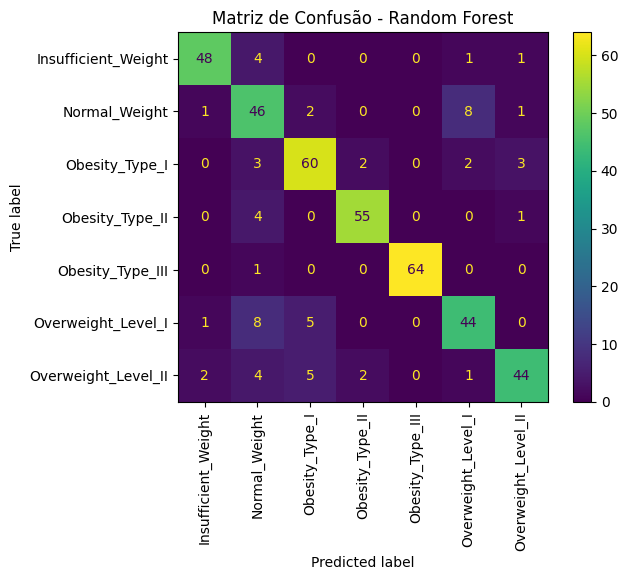

In [18]:
pipeline_rf, acc_rf = avaliar_modelo(
    "Random Forest",
    RandomForestClassifier(random_state=42, n_estimators=300)
)

## 19. Treinamento do modelo Gradient Boosting

O quarto modelo testado foi o Gradient Boosting por ele apresentar bom desempenho em problemas de classificação, sendo uma alternativa forte para comparar com o Random Forest.

Esse algoritmo também utiliza árvores de decisão, mas funciona de forma sequencial: cada nova árvore tenta corrigir os erros cometidos pelas árvores anteriores.

Gradient Boosting
Acurácia: 80.85 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.85      0.86        54
      Normal_Weight       0.66      0.76      0.70        58
     Obesity_Type_I       0.68      0.77      0.72        70
    Obesity_Type_II       0.92      0.90      0.91        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.78      0.66      0.71        58
Overweight_Level_II       0.82      0.72      0.77        58

           accuracy                           0.81       423
          macro avg       0.82      0.81      0.81       423
       weighted avg       0.82      0.81      0.81       423



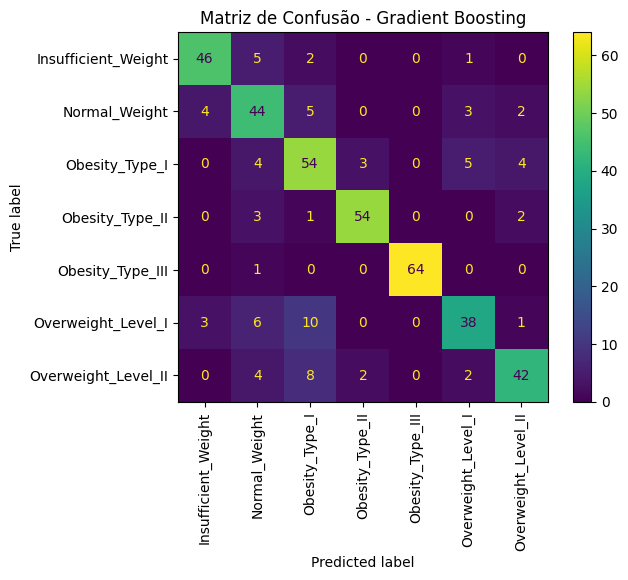

In [19]:
pipeline_gb, acc_gb = avaliar_modelo(
    "Gradient Boosting",
    GradientBoostingClassifier(random_state=42)
)

## 20. Comparação dos modelos treinados

Comparamos as acurácias dos quatro modelos em uma tabela e verificamos quais modelos atingiram 75% e qual apresentou o melhor desempenho geral.


In [20]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Acurácia": [
        acc_log,
        acc_tree,
        acc_rf,
        acc_gb
    ]
})

resultados["Acurácia (%)"] = resultados["Acurácia"] * 100

resultados.sort_values(by="Acurácia", ascending=False)

,Modelo,Acurácia,Acurácia (%)
2,Random Forest,0.853428,85.342790
3,Gradient Boosting,0.808511,80.851064
1,Árvore de Decisão,0.742317,74.231678
0,Regressão Logística,0.624113,62.411348


## 21. Visualização comparativa da acurácia dos modelos

Geramos um gráfico de barras para facilitar a comparação visual entre os modelos testados e ver qual teve maior desempenho.

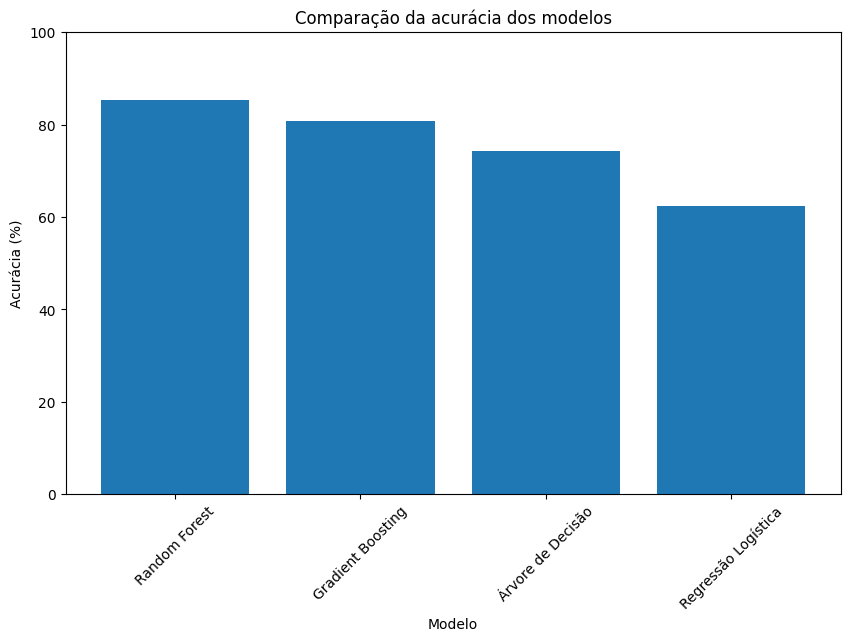

In [21]:
resultados_ordenados = resultados.sort_values(by="Acurácia (%)", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(resultados_ordenados["Modelo"], resultados_ordenados["Acurácia (%)"])
plt.title("Comparação da acurácia dos modelos")
plt.xlabel("Modelo")
plt.ylabel("Acurácia (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.show()

## 22. Escolha automática do melhor modelo

Selecionamos automaticamente o modelo com maior acurácia no conjunto de teste, então a aplicação em Streamlit poderá receber novos dados, aplicar automaticamente os mesmos tratamentos e gerar a previsão final

In [22]:
modelos_treinados = {
    "Regressão Logística": pipeline_log,
    "Árvore de Decisão": pipeline_tree,
    "Random Forest": pipeline_rf,
    "Gradient Boosting": pipeline_gb
}

acuracias = {
    "Regressão Logística": acc_log,
    "Árvore de Decisão": acc_tree,
    "Random Forest": acc_rf,
    "Gradient Boosting": acc_gb
}

nome_melhor_modelo = max(acuracias, key=acuracias.get)
melhor_modelo = modelos_treinados[nome_melhor_modelo]
melhor_acuracia = acuracias[nome_melhor_modelo]

print("Melhor modelo:", nome_melhor_modelo)
print("Acurácia:", round(melhor_acuracia * 100, 2), "%")

Melhor modelo: Random Forest
Acurácia: 85.34 %


## 23. Avaliação final do modelo escolhido

Avaliamos novamente o modelo escolhido usando os dados de teste para registrar o desempenho final do modelo.

Exibimos o nome do melhor modelo, a acurácia final e um relatório de classificação com precision, recall e f1-score

In [23]:
y_pred_final = melhor_modelo.predict(X_test)

print("Melhor modelo:", nome_melhor_modelo)
print("Acurácia final:", round(melhor_acuracia * 100, 2), "%")

print(classification_report(
    y_test,
    y_pred_final,
    target_names=label_encoder.classes_
))

Melhor modelo: Random Forest
Acurácia final: 85.34 %
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.89      0.91        54
      Normal_Weight       0.66      0.79      0.72        58
     Obesity_Type_I       0.83      0.86      0.85        70
    Obesity_Type_II       0.93      0.92      0.92        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.79      0.76      0.77        58
Overweight_Level_II       0.88      0.76      0.81        58

           accuracy                           0.85       423
          macro avg       0.86      0.85      0.85       423
       weighted avg       0.86      0.85      0.86       423



## 24. Matriz de confusão do modelo escolhido

A matriz de confusão mostra quantos registros foram classificados corretamente e quantos foram confundidos com outras classes, identificando em quais níveis de obesidade o modelo apresenta melhor desempenho.

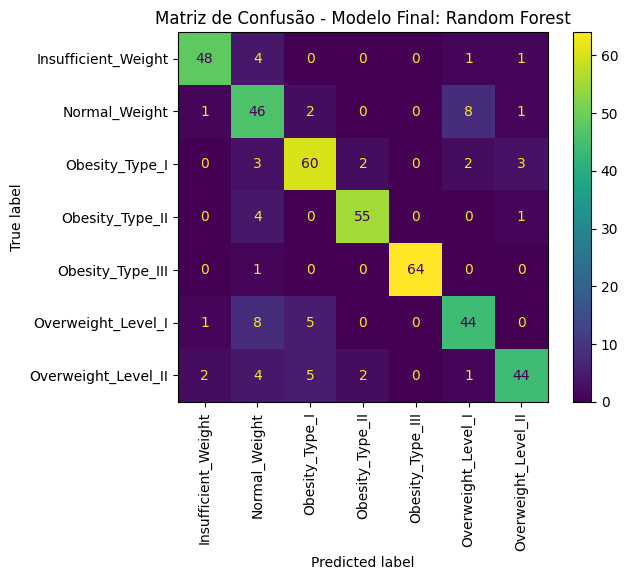

In [24]:
matriz_final = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_final,
    display_labels=label_encoder.classes_
)

disp.plot(xticks_rotation=90)
plt.title(f"Matriz de Confusão - Modelo Final: {nome_melhor_modelo}")
plt.show()

## 26. Salvamento do modelo final

Salvamos dois arquivos:
1. modelo_obesidade.joblib contém a pipeline completa, incluindo o pré-processamento e o modelo treinado;
2. label_encoder_obesidade.joblib contém o codificador da variável alvo, usado para converter os números previstos de volta para os nomes das classes.


In [25]:
joblib.dump(melhor_modelo, "../models/modelo_obesidade.joblib")
joblib.dump(label_encoder, "../models/label_encoder_obesidade.joblib")

['../models/label_encoder_obesidade.joblib']

## 27. Conclusão

Construimos uma pipeline completa de Machine Learning para classificação do nível de obesidade.

A pipeline contém o pré-processamento das variáveis numéricas e categóricas, garantindo que os dados sejam tratados de forma padronizada antes de serem enviados ao modelo.

Foram testados quatro modelos de classificação:

- Regressão Logística;
- Árvore de Decisão;
- Random Forest;
- Gradient Boosting.

E após a comparação dos resultados, foi selecionado o Random Forest como modelo de melhor desempenho, com uma acurácia superior a 85%.

Por fim, o pipeline final e o codificador da variável alvo foram salvos em arquivos .joblib, para serem usados na aplicação preditiva em Streamlit.